LAB 4:  BÀI THỰC HÀNH CHUẨN BỊ DỮ LIỆU 
PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING
1. Viết hàm load_data() để tải dữ liệu lên ứng dụng. Sau đó, hiển thị ra màn hình 10 dòng đầu tiên.

In [125]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Cấu hình hiển thị biểu đồ đẹp và đồng bộ hơn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

def load_data(file_path):
    df = pd.read_csv(file_path)
    return df

# Đọc file dữ liệu bạn vừa tải lên
df = load_data('titanic_disaster.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


2. Thống kê dữ liệu thiếu trên các biến số và trực quan hóa dữ liệu thiếu bằng biểu đồ (Heat map). Hãy cho nhận xét về tình trạng thiếu dữ liệu Age, Cabin và Embarked 

Thống kê dữ liệu thiếu trên các biến:
          Số lượng thiếu  Tỉ lệ (%)
Age                  177  19.865320
Cabin                687  77.104377
Embarked               2   0.224467


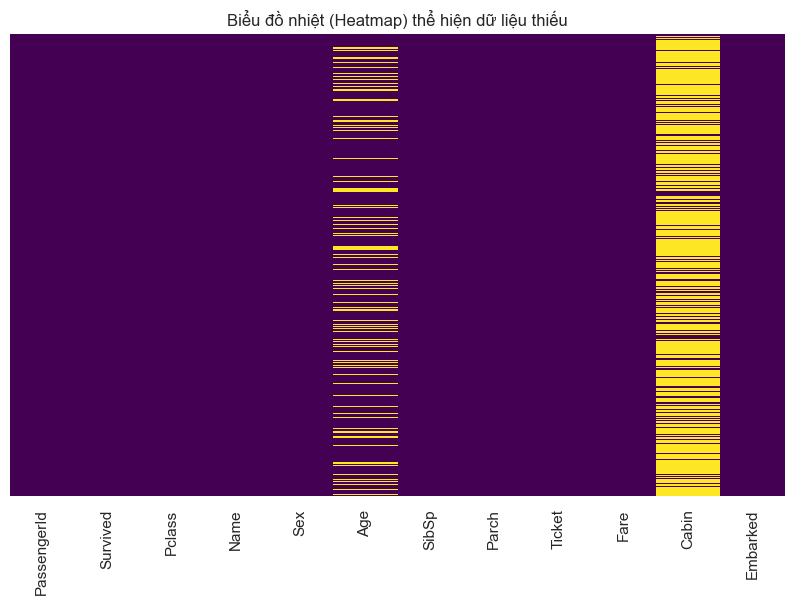

In [126]:
# Thống kê số lượng và tỷ lệ giá trị thiếu
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Số lượng thiếu': missing_count, 'Tỉ lệ (%)': missing_percentage})
print("Thống kê dữ liệu thiếu trên các biến:")
print(missing_df[missing_df['Số lượng thiếu'] > 0])

# Trực quan hóa bằng Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Biểu đồ nhiệt (Heatmap) thể hiện dữ liệu thiếu')
plt.show()

3. Xử lý tên cột tên Name, tách ra làm 2 cột: firstName và secondName. Lưu ý: Sau khi tách cột xong thì xóa luôn cột Name 

In [127]:
# Tách dựa trên dấu phẩy đầu tiên ngăn cách giữa Họ và Tên/Danh xưng
df[['firstName', 'secondName']] = df['Name'].str.split(',', n=1, expand=True)

# Làm sạch khoảng trắng thừa ở hai đầu chuỗi ký tự
df['firstName'] = df['firstName'].str.strip()
df['secondName'] = df['secondName'].str.strip()

# Xóa bỏ cột Name gốc khỏi DataFrame
df.drop(columns=['Name'], inplace=True)

# Hiển thị kiểm tra 5 dòng đầu sau khi tách
df[['firstName', 'secondName']].head()

,firstName,secondName
0,Braund,Mr. Owen Harris
1,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,Heikkinen,Miss. Laina
3,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,Allen,Mr. William Henry


4. Xứ lý rút gọn kích thước dữ liệu trên cột Sex như sau: thay thế male→ M và female → F 

In [128]:
df['Sex'] = df['Sex'].map({'male': 'M', 'female': 'F'})
print("Tần suất sau khi rút gọn cột Sex:")
print(df['Sex'].value_counts())

Tần suất sau khi rút gọn cột Sex:
M    577
F    314
Name: Sex, dtype: int64


5. Xử lý dữ liệu thiếu trên biến Age bằng cách thay thế bằng giá trị trung bình tuổi: Hãy đưa ra quyết định dùng giá trị trung bình tuổi toàn bộ hành khách hay theo từng nhóm hạng vé (hạng hành khách: Pclass). Ta tiến hành làm các bước sau:

a. Sử dụng Seaborn để vẽ biểu đồ (Box plot) trực quan dữ liệu để xác định phân phối tuổi trên từng hạng hành khách. Nhận xét về tuổi trung bình giữa các nhóm hành khách. Từ đó đưa ra quyết định cách thay thế giá trị tuổi bị thiếu. 

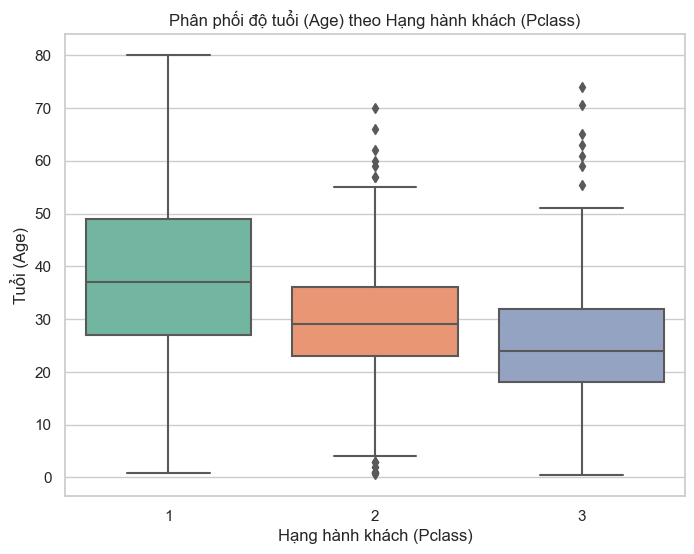

In [129]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')
plt.title('Phân phối độ tuổi (Age) theo Hạng hành khách (Pclass)')
plt.xlabel('Hạng hành khách (Pclass)')
plt.ylabel('Tuổi (Age)')
plt.show()

b. Tiến hành thay thế giá trị Age bị thiếu. Sau đó, hiển thị kết quả dạng bảng và trực quan dữ liệu đã xử lý thiếu cho cột’Age’ bằng biểu đồ Heat map. 

Số lượng dòng thiếu ở cột Age sau xử lý nhóm: 0


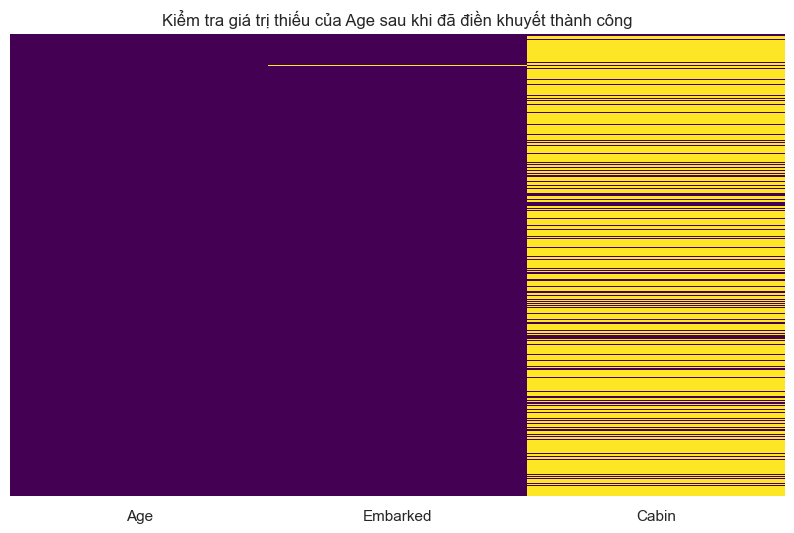

In [130]:
# Tính toán giá trị trung vị độ tuổi của từng hạng vé (Pclass)
age_median_by_pclass = df.groupby('Pclass')['Age'].transform('median')

# Điền các giá trị thiếu (NaN) của cột Age dựa vào giá trị trung vị tương ứng của hạng vé đó
df['Age'] = df['Age'].fillna(age_median_by_pclass)

print(f"Số lượng dòng thiếu ở cột Age sau xử lý nhóm: {df['Age'].isnull().sum()}")

# Vẽ lại đồ thị Heatmap để kiểm tra dữ liệu sạch sau xử lý câu 5
plt.figure(figsize=(10, 6))
sns.heatmap(df[['Age', 'Embarked', 'Cabin']].isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Kiểm tra giá trị thiếu của Age sau khi đã điền khuyết thành công')
plt.show()

6. Xây dựng biến số Agegroup có thang đo thứ tự được ánh xạ theo thang đo khoảng dựa trên độ tuổi của hành khách như sau: (age =< 12] → Kid; (12, 18]: Teen, (18, 60]: Adult và ( age > 60): Older

In [131]:
# Định nghĩa các khoảng cắt (bins) và nhãn tên tương ứng
# -1 để bao hàm cả các bé 0 tuổi
bins = [-1, 12, 18, 60, np.inf]
labels = ['Kid', 'Teen', 'Adult', 'Older']

df['Agegroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
print("Số lượng hành khách theo từng nhóm tuổi:")
print(df['Agegroup'].value_counts())

Số lượng hành khách theo từng nhóm tuổi:
Adult    730
Teen      70
Kid       69
Older     22
Name: Agegroup, dtype: int64


7. Tiến hành thêm đặc trưng về danh xưng (namePrefix) trong xã hội bằng cách tách  Mr, Mrs, Miss, Master ra khỏi “secondName” 

In [132]:
# Danh xưng tiếng Anh thường kết thúc bằng dấu chấm (Mr., Mrs., Miss.,...) nằm trong cột secondName
df['namePrefix'] = df['secondName'].str.extract(r'([A-Za-z]+)\.')

print("Thống kê các danh xưng trích xuất được:")
print(df['namePrefix'].value_counts().head(10))

Thống kê các danh xưng trích xuất được:
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Name: namePrefix, dtype: int64


8. Khai thác thêm thông tin số lượng thành viên đi theo nhóm thân quen (familySize) đối với mỗi hành khách trên chuyến hải trình; family size = 1+ SibSp + Parch

In [133]:
df['familySize'] = 1 + df['SibSp'] + df['Parch']
df['familySize'].value_counts()

1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: familySize, dtype: int64

9. Tạo thêm đặc trưng ‘Alone’ để xác định hành khách đi theo nhóm hay cá nhân bằng cách dựa trên familySize như sau: Nếu familySize = 0 thì giá trị Alone = 1 và ngược lại là 0.

In [134]:
df['Alone'] = np.where(df['familySize'] == 1, 1, 0)
print("Thống kê trạng thái đi một mình (1: Đi một mình, 0: Đi cùng người thân):")
print(df['Alone'].value_counts())

Thống kê trạng thái đi một mình (1: Đi một mình, 0: Đi cùng người thân):
1    537
0    354
Name: Alone, dtype: int64


10. Tiến hành tách loại cabin (typeCabin) mà hành khách ở để lọc và phân tích đặc tính cabin. Loại cabin được kí hiệu bởi chữ cái đầu tiên. Lưu ý: Đối với dữ liệu cabin bị thiếu thì thay thế bằng “Unknown” 

In [135]:
# Điền giá trị trống của Cabin bằng chuỗi 'Unknown'
df['Cabin'] = df['Cabin'].fillna('Unknown')

# Trích xuất ký tự đầu tiên đại diện cho tầng/loại cabin (A, B, C, D, E, F, G, T, U...)
df['typeCabin'] = df['Cabin'].str[0]
print("Số lượng hành khách theo phân loại Cabin:")
print(df['typeCabin'].value_counts()) 

Số lượng hành khách theo phân loại Cabin:
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: typeCabin, dtype: int64


11. Loại bỏ dữ liệu thừa đối với các hành khách xuất hiện trong cả 2 tập dữ liệu huấn luyện  (train.csv) và đánh giá (test.csv). Ưu tiên giữ lại dữ liệu trong tập huấn luyện. 

In [136]:
# Định nghĩa các trường thông tin đặc trưng để xác định một hành khách trùng lặp
features_to_check = ['firstName', 'secondName', 'Age', 'Fare', 'Pclass']

# Tiến hành loại bỏ trùng lặp, giữ lại bản ghi xuất hiện đầu tiên (Ưu tiên tập huấn luyện ban đầu)
df.drop_duplicates(subset=features_to_check, keep='first', inplace=True)
print(f"Kích thước tập dữ liệu hiện tại sau khi lọc trùng: {df.shape}")

Kích thước tập dữ liệu hiện tại sau khi lọc trùng: (891, 18)


PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA 
12. Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính. 

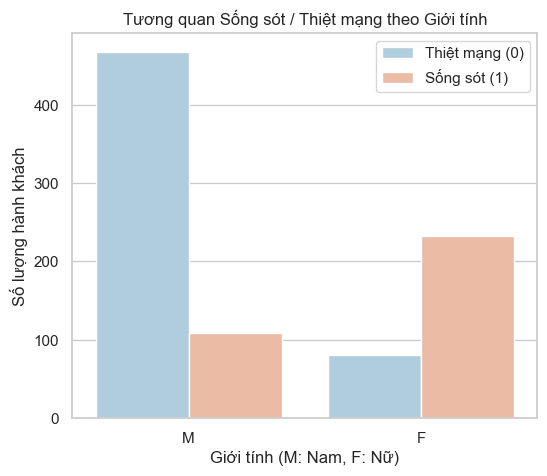

In [137]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Sex', hue='Survived', data=df, palette='RdBu_r')
plt.title('Tương quan Sống sót / Thiệt mạng theo Giới tính')
plt.xlabel('Giới tính (M: Nam, F: Nữ)')
plt.ylabel('Số lượng hành khách')
plt.legend(['Thiệt mạng (0)', 'Sống sót (1)'])
plt.show()

13. Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách (Pclass).

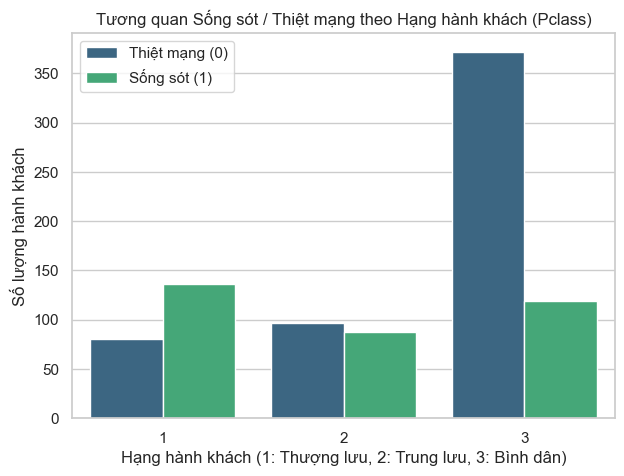

In [138]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='viridis')
plt.title('Tương quan Sống sót / Thiệt mạng theo Hạng hành khách (Pclass)')
plt.xlabel('Hạng hành khách (1: Thượng lưu, 2: Trung lưu, 3: Bình dân)')
plt.ylabel('Số lượng hành khách')
plt.legend(['Thiệt mạng (0)', 'Sống sót (1)'])
plt.show()

14. Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác 

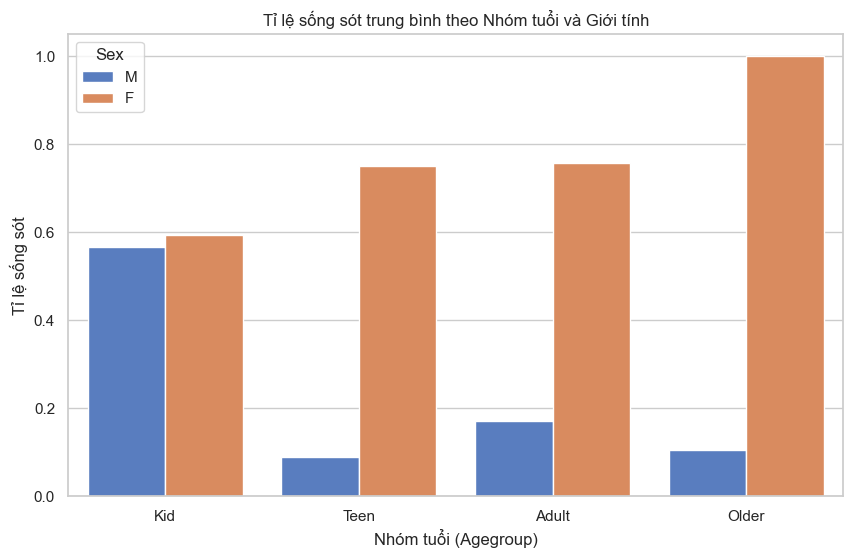

In [139]:
plt.figure(figsize=(10, 6))
# Thay errorbar=None bằng ci=None để tương thích với Seaborn bản cũ
sns.barplot(x='Agegroup', y='Survived', hue='Sex', data=df, ci=None, palette='muted')
plt.title('Tỉ lệ sống sót trung bình theo Nhóm tuổi và Giới tính')
plt.xlabel('Nhóm tuổi (Agegroup)')
plt.ylabel('Tỉ lệ sống sót')
plt.show()

15. Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng

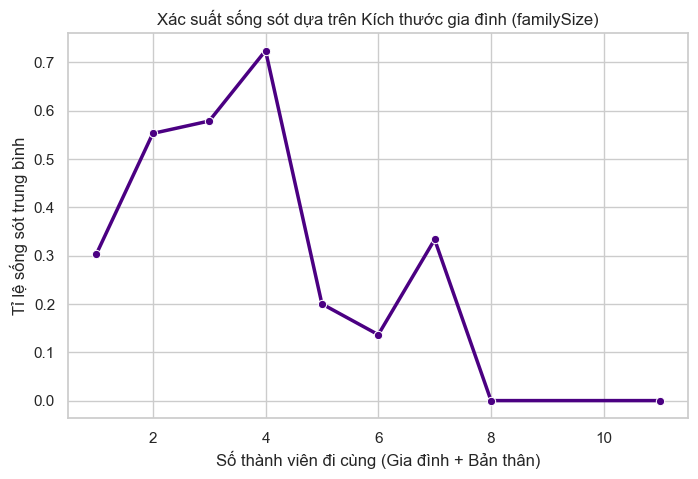

In [140]:
plt.figure(figsize=(8, 5))
# Thay errorbar=None bằng ci=None để tương thích với Seaborn bản cũ của bạn
sns.lineplot(x='familySize', y='Survived', data=df, marker='o', ci=None, color='indigo', linewidth=2.5)
plt.title('Xác suất sống sót dựa trên Kích thước gia đình (familySize)')
plt.xlabel('Số thành viên đi cùng (Gia đình + Bản thân)')
plt.ylabel('Tỉ lệ sống sót trung bình')
plt.show()

16. Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé 

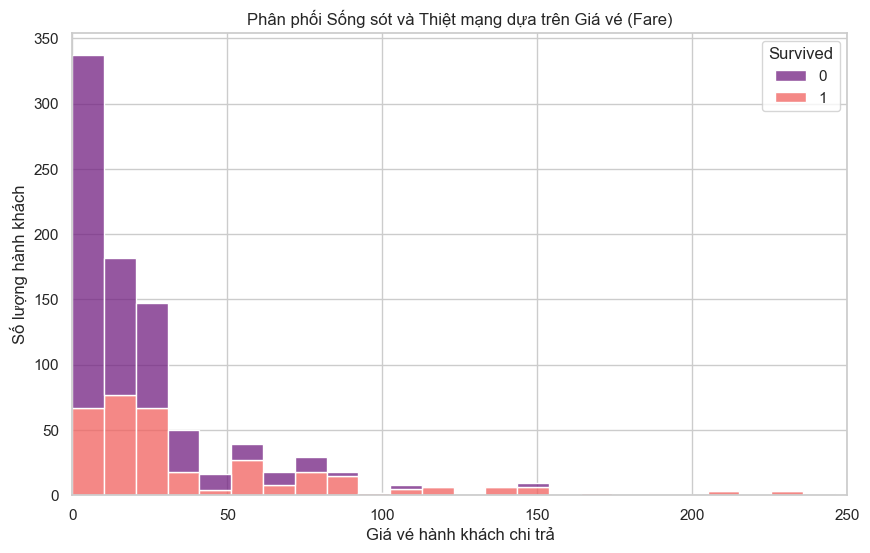

In [141]:
plt.figure(figsize=(10, 6))
# Dùng histplot xếp chồng (multiple="stack") để nhìn rõ mối tương quan
sns.histplot(data=df, x='Fare', hue='Survived', multiple='stack', bins=50, palette='magma')
plt.title('Phân phối Sống sót và Thiệt mạng dựa trên Giá vé (Fare)')
plt.xlabel('Giá vé hành khách chi trả')
plt.ylabel('Số lượng hành khách')
plt.xlim(0, 250) # Giới hạn dải vé phổ biến để biểu đồ không bị kéo quá dài do giá vé ngoại lai (outliers)
plt.show()

17. Trực quan số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) hành khách và cảng sẽ cập bến. 

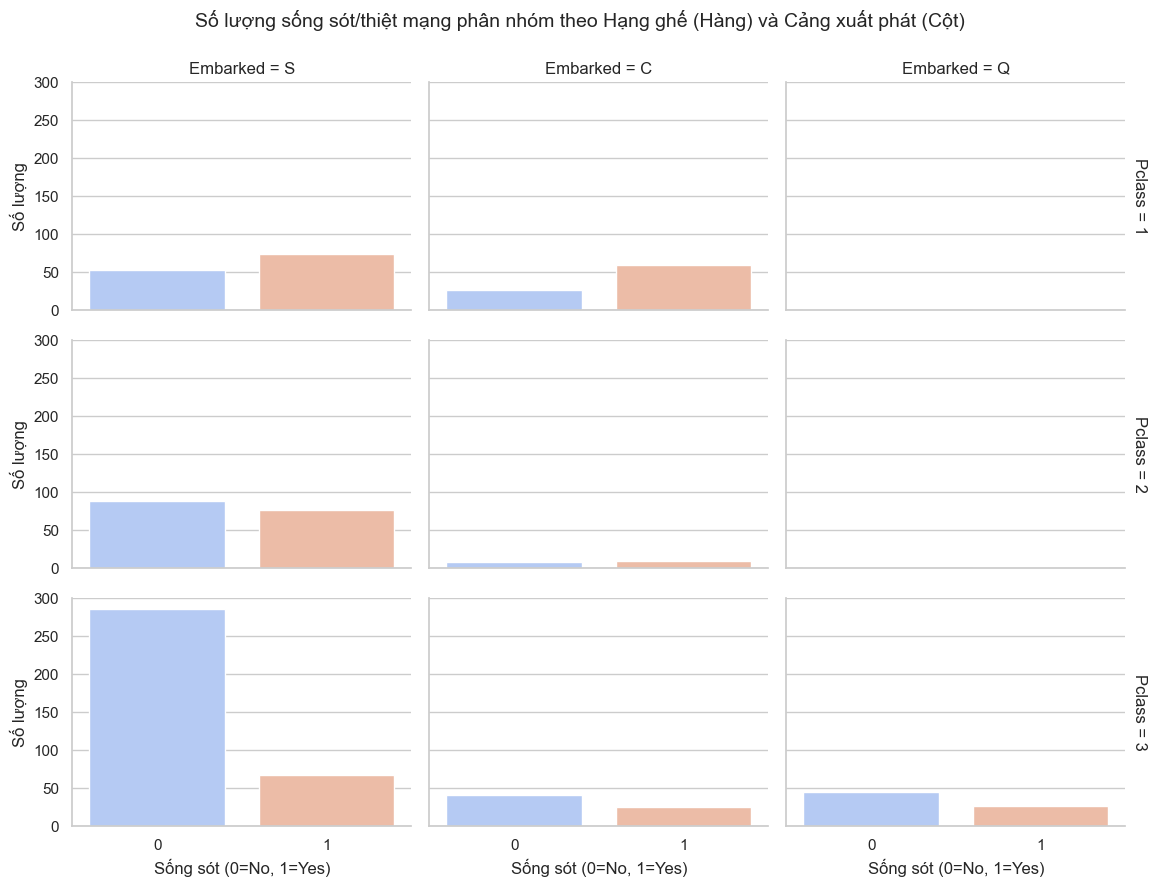

In [142]:
# Tạo lưới biểu đồ (FacetGrid) với Hàng tương ứng Pclass và Cột tương ứng Embarked
g = sns.FacetGrid(df, col="Embarked", row="Pclass", margin_titles=True, height=3, aspect=1.3)
g.map(sns.countplot, "Survived", order=[0, 1], palette="coolwarm")
g.set_axis_labels("Sống sót (0=No, 1=Yes)", "Số lượng")

# Tinh chỉnh tiêu đề tổng thể cho lưới biểu đồ
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Số lượng sống sót/thiệt mạng phân nhóm theo Hạng ghế (Hàng) và Cảng xuất phát (Cột)', fontsize=14)
plt.show()